In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img_bgr = cv2.imread("fuji.webp")

img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

rows, cols, channels = img.shape

def show_images(titles, images, figsize=(10, 5)):
    plt.figure(figsize=figsize)
    for i in range(len(images)):
        plt.subplot(1, len(images), i + 1)
        plt.imshow(images[i])
        plt.title(titles[i])
        plt.axis('off')
    plt.show()

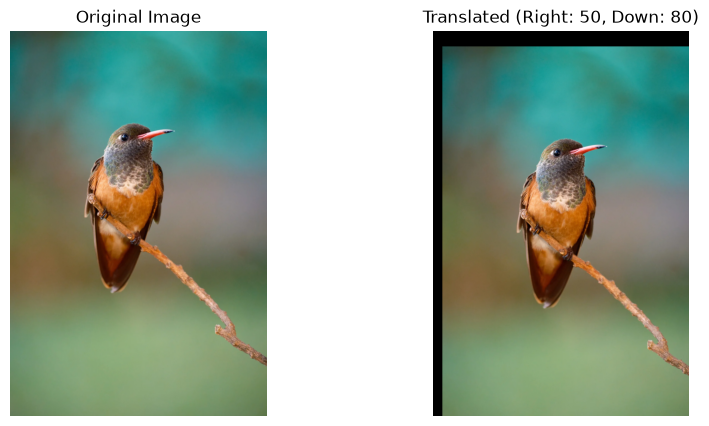

In [5]:
M_translate = np.float32([[1, 0, 50], [0, 1, 80]])

translated_img = cv2.warpAffine(img, M_translate, (cols, rows))

show_images(['Original Image', 'Translated (Right: 50, Down: 80)'], [img, translated_img])

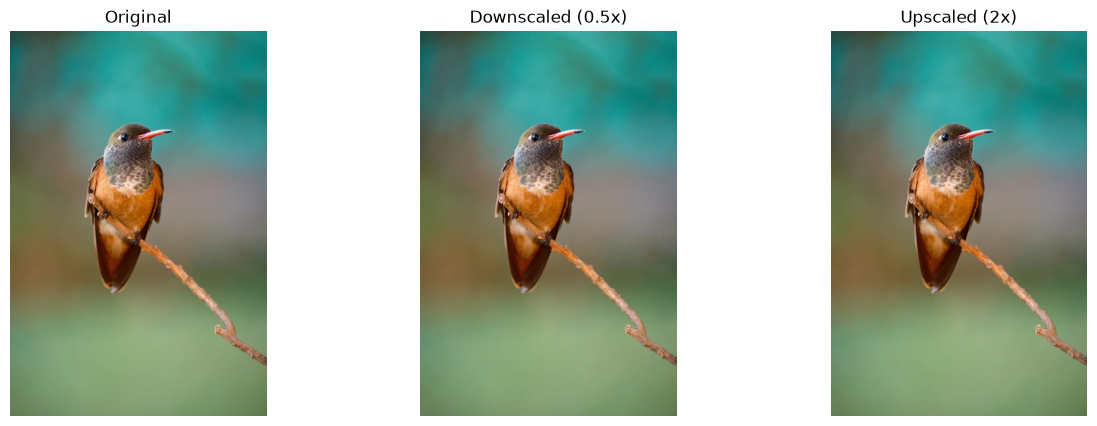

In [7]:
img_downscaled = cv2.resize(img, None, fx=0.5, fy=0.5, interpolation=cv2.INTER_LINEAR)

img_upscaled = cv2.resize(img, None, fx=2.0, fy=2.0, interpolation=cv2.INTER_LINEAR)
show_images(['Original', 'Downscaled (0.5x)', 'Upscaled (2x)'], 
            [img, img_downscaled, img_upscaled], figsize=(15, 5))

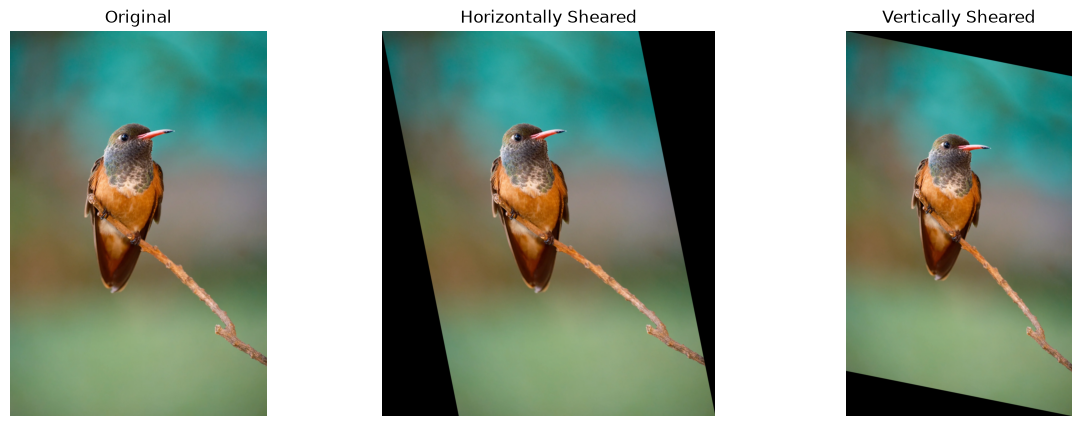

In [8]:
shear_factor = 0.2

M_shear_h = np.float32([
    [1, shear_factor, 0],
    [0, 1, 0]
])

sheared_h_img = cv2.warpAffine(img, M_shear_h, (cols + int(shear_factor * rows), rows))

M_shear_v = np.float32([
    [1, 0, 0],
    [shear_factor, 1, 0]
])

sheared_v_img = cv2.warpAffine(img, M_shear_v, (cols, rows + int(shear_factor * cols)))

show_images(['Original', 'Horizontally Sheared', 'Vertically Sheared'], 
            [img, sheared_h_img, sheared_v_img], figsize=(15, 5))

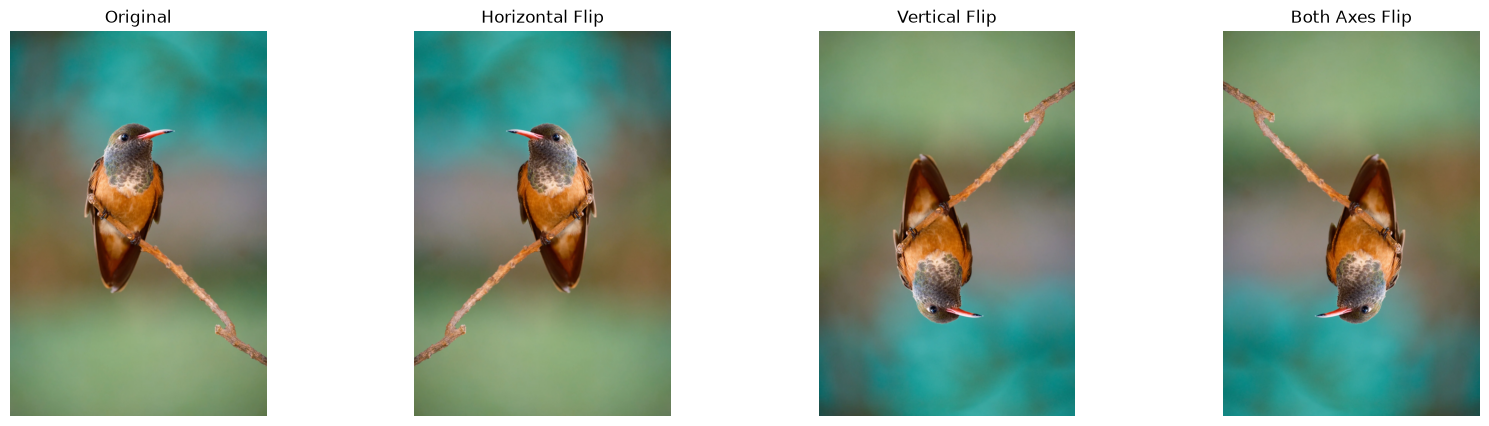

In [10]:
flip_horizontal = cv2.flip(img, 1)

flip_vertical = cv2.flip(img, 0)


flip_both = cv2.flip(img, -1)

show_images(['Original', 'Horizontal Flip', 'Vertical Flip', 'Both Axes Flip'], 
            [img, flip_horizontal, flip_vertical, flip_both], figsize=(20, 5))

In [ ]:
center = (cols // 2, rows // 2)
M_rot_45 = cv2.getRotationMatrix2D(center, 45, 1.0)
rotated_45_img = cv2.warpAffine(img, M_rot_45, (cols, rows))


M_rot_90 = cv2.getRotationMatrix2D(center, 90, 1.0)
rotated_90_img = cv2.warpAffine(img, M_rot_90, (cols, rows))

# Display original and rotated images
show_images(['Original', '45° Rotation', '90° Rotation'], 
            [img, rotated_45_img, rotated_90_img], figsize=(15, 5))